# Hệ thống Dự đoán Rủi ro Tín dụng và Đề xuất Thu hồi nợ

Notebook trình bày đầy đủ **8 bước** của một pipeline Machine Learning áp dụng cho
bài toán dự đoán vỡ nợ thẻ tín dụng và đề xuất thu hồi nợ:

1. Khám phá dữ liệu (EDA)
2. Phân tích dữ liệu
3. Tiền xử lý dữ liệu
4. Huấn luyện mô hình (Training)
5. Tinh chỉnh tham số (Hyperparameter tuning)
6. Đánh giá hiệu suất mô hình theo metric
7. Diễn giải mô hình
8. Đề xuất thu hồi nợ

**Dữ liệu:** UCI *Default of Credit Card Clients* — 30.000 khách hàng thẻ tín dụng tại
Đài Loan, 23 biến đầu vào, biến mục tiêu nhị phân `default.payment.next.month`
(1 = vỡ nợ tháng sau, 0 = không vỡ nợ). Đối chiếu với paper gốc: Yeh & Lien (2009),
*Expert Systems with Applications* 36, 2473-2480.

Các hàm dùng chung (nạp dữ liệu, làm sạch, feature engineering, huấn luyện, đánh giá,
SHAP, xếp hạng ưu tiên) được viết sẵn trong thư mục `src/` để có thể tái sử dụng ở
`python -m src.pipeline`. Notebook này gọi lại các hàm đó, đồng thời viết thêm code
trực tiếp (không qua `src/`) ở những bước cần diễn giải chi tiết, dễ hiểu (EDA, phân
tích, đánh giá, đề xuất thu hồi nợ).


**Version 2 (file rieng, khong ghi de `01_credit_risk_pipeline.ipynb`):** them 2 model boosting (**GBM**, **LightGBM**) vao pipeline chinh o Buoc 4-5 (`src/models_v2.py`, mo rong tu `src/models.py` bang import, khong sua file goc), va mot **thi nghiem so sanh rieng** o Buoc 5b thu SMOTE (`src/resampling_experiment_v2.py`), **khong thay the** cach xu ly mat can bang bang `class_weight` hien co. Tham khao huong di cua Ampomah et al. (2025), `papers/paper 2.pdf` — chi lay chon loc phan model boosting, khong dua thang Boruta/DBSCAN/SMOTE vao pipeline chinh (xem giai thich chi tiet o Buoc 5b).

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # de import duoc package "src"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

from src.config import (
    BILL_AMT_COLS,
    PAY_AMT_COLS,
    PAY_COLS,
    RANDOM_STATE,
    TARGET_COL,
)
from src.data import clean, load_raw, split
from src.evaluate import build_paper_comparison_table
from src.features import add_derived_features, build_preprocessor, compute_vif
from src.priority import build_priority_ranking

# --- Version 2: import tu cac module MOI, khong sua doi src/models.py, ---
# --- src/evaluate.py, src/pipeline.py goc. ---
from src.models_v2 import PARAM_GRIDS, train_all_models
from src.evaluate_v2 import build_metrics_table
from src.resampling_experiment_v2 import build_resampling_comparison_table, run_smote_experiment

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## Bước 1. Khám phá dữ liệu (EDA)

Mục tiêu: hiểu cấu trúc dữ liệu (số dòng/cột, kiểu dữ liệu, giá trị thiếu), thống kê mô
tả cơ bản, và phát hiện các giá trị bất thường cần xử lý ở Bước 3.


In [2]:
df_raw = load_raw()
print("Kich thuoc du lieu (so dong, so cot):", df_raw.shape)
df_raw.head()


Kich thuoc du lieu (so dong, so cot): (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
# Kieu du lieu tung cot, so gia tri non-null -> phat hien nhanh cot bi thieu du lieu
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
# Thong ke mo ta cho toan bo bien so (count, mean, std, min, các mốc phan vi, max)
# .T (transpose) de moi bien la 1 dong, de doc hon khi co 23+ cot
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [5]:
# Kiem tra gia tri thieu (missing values) va dong trung lap
print("So gia tri thieu theo tung cot:")
print(df_raw.isnull().sum().sum(), "gia tri thieu trong toan bo dataset")

print("\nSo dong trung lap (theo ID):", df_raw["ID"].duplicated().sum())


So gia tri thieu theo tung cot:
0 gia tri thieu trong toan bo dataset

So dong trung lap (theo ID): 0


Ty le khach hang vo no (default = 1): 22.12%
Ty le khach hang KHONG vo no (default = 0): 77.88%
=> Du lieu mat can bang (imbalanced): can luu y khi chon metric va huan luyen mo hinh.


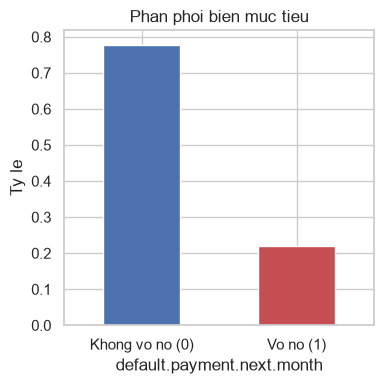

In [6]:
# Phan phoi bien muc tieu -- kiem tra muc do mat can bang
default_rate = df_raw[TARGET_COL].mean()
print(f"Ty le khach hang vo no (default = 1): {default_rate:.2%}")
print(f"Ty le khach hang KHONG vo no (default = 0): {1 - default_rate:.2%}")
print("=> Du lieu mat can bang (imbalanced): can luu y khi chon metric va huan luyen mo hinh.")

fig, ax = plt.subplots(figsize=(4, 4))
df_raw[TARGET_COL].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.set_xticklabels(["Khong vo no (0)", "Vo no (1)"], rotation=0)
ax.set_ylabel("Ty le")
ax.set_title("Phan phoi bien muc tieu")
plt.tight_layout()
plt.show()


In [7]:
# Gia tri bat thuong trong cac bien phan loai (truoc khi lam sach o Buoc 3)
print("SEX (1 = nam, 2 = nu):")
print(df_raw["SEX"].value_counts().sort_index())

print("\nEDUCATION (dinh nghia goc: 1=sau dai hoc, 2=dai hoc, 3=thpt, 4=khac):")
print("=> Cac gia tri 0, 5, 6 KHONG nam trong dinh nghia goc:")
print(df_raw["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE (dinh nghia goc: 1=da ket hon, 2=doc than, 3=khac):")
print("=> Gia tri 0 KHONG nam trong dinh nghia goc:")
print(df_raw["MARRIAGE"].value_counts().sort_index())

print("\nPAY_1 (tinh trang thanh toan thang gan nhat; -2/-1/0 = khong tre han, >=1 = so thang tre han):")
print(df_raw["PAY_0"].value_counts().sort_index())


SEX (1 = nam, 2 = nu):
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION (dinh nghia goc: 1=sau dai hoc, 2=dai hoc, 3=thpt, 4=khac):
=> Cac gia tri 0, 5, 6 KHONG nam trong dinh nghia goc:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE (dinh nghia goc: 1=da ket hon, 2=doc than, 3=khac):
=> Gia tri 0 KHONG nam trong dinh nghia goc:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

PAY_1 (tinh trang thanh toan thang gan nhat; -2/-1/0 = khong tre han, >=1 = so thang tre han):
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


## Bước 2. Phân tích dữ liệu

Sau khi khám phá cấu trúc dữ liệu, ta đi sâu phân tích **mối quan hệ giữa các biến đầu
vào và biến mục tiêu**, cũng như **mối quan hệ giữa các biến với nhau** (đa cộng
tuyến) — làm cơ sở cho các quyết định ở Bước 3 (Tiền xử lý / Feature engineering).


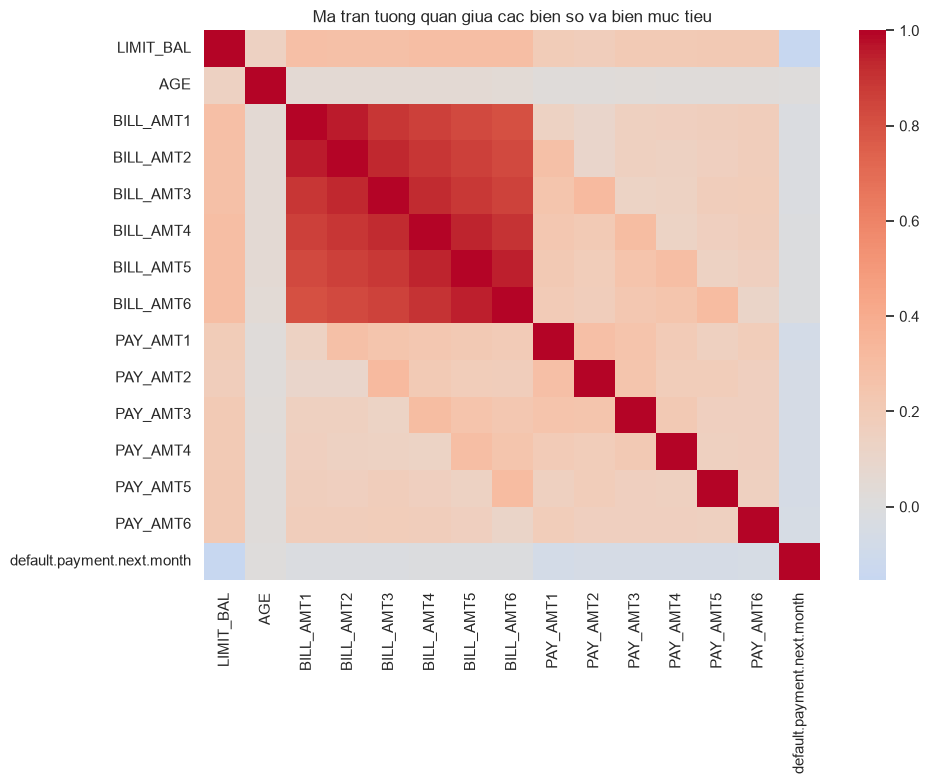

Tuong quan cua tung bien voi bien muc tieu (sap xep giam dan theo tri tuyet doi):
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: default.payment.next.month, dtype: float64


In [8]:
# Ma tran tuong quan giua cac bien so va bien muc tieu
numeric_cols = ["LIMIT_BAL", "AGE"] + BILL_AMT_COLS + PAY_AMT_COLS + [TARGET_COL]
corr = df_raw[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Ma tran tuong quan giua cac bien so va bien muc tieu")
plt.tight_layout()
plt.show()

print("Tuong quan cua tung bien voi bien muc tieu (sap xep giam dan theo tri tuyet doi):")
print(corr[TARGET_COL].drop(TARGET_COL).sort_values(key=lambda s: s.abs(), ascending=False))


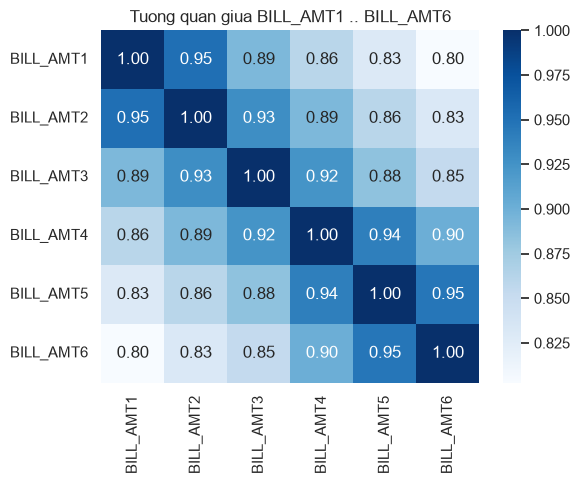

     feature        VIF
1  BILL_AMT2  23.660203
4  BILL_AMT5  22.604274
3  BILL_AMT4  19.294916
2  BILL_AMT3  15.685823
0  BILL_AMT1  15.676637
5  BILL_AMT6  13.820638


In [9]:
# BILL_AMT1..BILL_AMT6 thuong tuong quan rat cao voi nhau (du no hang thang it bien dong)
# -> nguy co da cong tuyen (multicollinearity), anh huong dac biet den Logistic Regression.
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_raw[BILL_AMT_COLS].corr(), cmap="Blues", annot=True, fmt=".2f", ax=ax)
ax.set_title("Tuong quan giua BILL_AMT1 .. BILL_AMT6")
plt.tight_layout()
plt.show()

# Dinh luong da cong tuyen bang VIF (Variance Inflation Factor): VIF > 10 la dau hieu manh
vif_table = compute_vif(clean(df_raw), BILL_AMT_COLS)
print(vif_table)


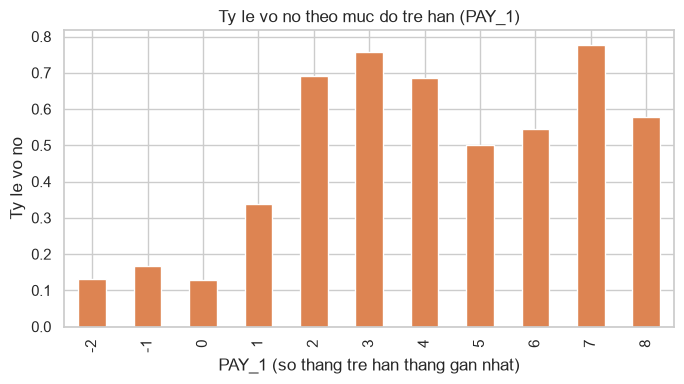

In [10]:
# Ty le vo no theo tung nhom PAY_1 (muc do tre han thang gan nhat)
# -> Ky vong: tre han cang nhieu thang thi ty le vo no cang cao.
pay1_default = df_raw.rename(columns={"PAY_0": "PAY_1"}).groupby("PAY_1")[TARGET_COL].mean()

fig, ax = plt.subplots(figsize=(7, 4))
pay1_default.sort_index().plot(kind="bar", ax=ax, color="#DD8452")
ax.set_xlabel("PAY_1 (so thang tre han thang gan nhat)")
ax.set_ylabel("Ty le vo no")
ax.set_title("Ty le vo no theo muc do tre han (PAY_1)")
plt.tight_layout()
plt.show()


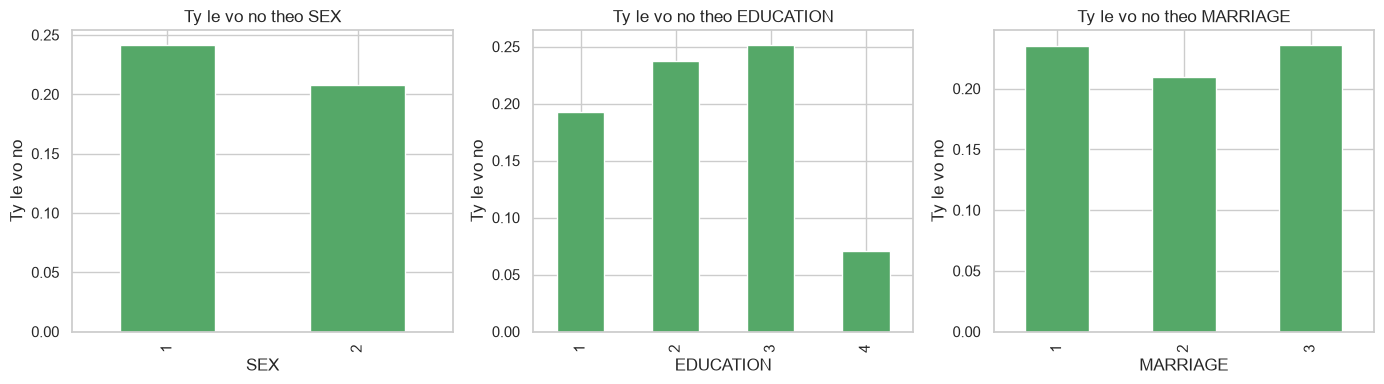

In [11]:
# Ty le vo no theo SEX / EDUCATION / MARRIAGE -- kiem tra co su khac biet dang ke giua cac nhom
df_group = clean(df_raw)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"]):
    df_group.groupby(col)[TARGET_COL].mean().plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(f"Ty le vo no theo {col}")
    ax.set_ylabel("Ty le vo no")
plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_17096\614367258.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Khong vo no", "Vo no"])
C:\Users\Admin\AppData\Local\Temp\ipykernel_17096\614367258.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Khong vo no", "Vo no"])


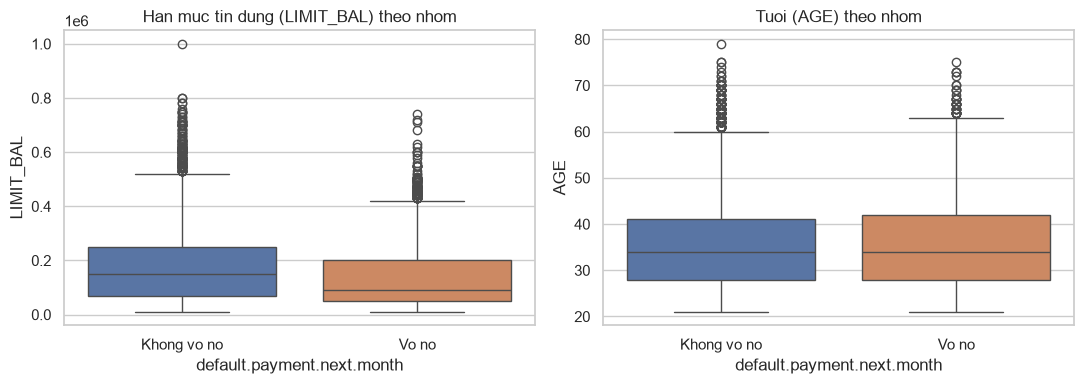

=> Nhan xet: khach hang vo no thuong co LIMIT_BAL (han muc) thap hon.


In [12]:
# Phan phoi LIMIT_BAL (han muc tin dung) va AGE theo tung nhom vo no / khong vo no
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df_raw, x=TARGET_COL, y="LIMIT_BAL", hue=TARGET_COL, legend=False, ax=axes[0])
axes[0].set_xticklabels(["Khong vo no", "Vo no"])
axes[0].set_title("Han muc tin dung (LIMIT_BAL) theo nhom")

sns.boxplot(data=df_raw, x=TARGET_COL, y="AGE", hue=TARGET_COL, legend=False, ax=axes[1])
axes[1].set_xticklabels(["Khong vo no", "Vo no"])
axes[1].set_title("Tuoi (AGE) theo nhom")
plt.tight_layout()
plt.show()

print("=> Nhan xet: khach hang vo no thuong co LIMIT_BAL (han muc) thap hon.")


**Tóm tắt Bước 2:**

- `PAY_1..PAY_6` (mức độ trễ hạn) có tương quan mạnh nhất với biến mục tiêu — đây sẽ là
  nhóm đặc trưng quan trọng nhất cho mô hình (được xác nhận lại bằng SHAP ở Bước 7).
- `BILL_AMT1..BILL_AMT6` tương quan rất cao với nhau (đa cộng tuyến, VIF lớn) → cần xử
  lý ở Bước 3 bằng cách thêm đặc trưng tổng hợp thay vì dùng toàn bộ 6 cột thô.
- `LIMIT_BAL` thấp và `PAY_n` trễ hạn nhiều đi kèm tỷ lệ vỡ nợ cao hơn rõ rệt.


## Bước 3. Tiền xử lý dữ liệu

Gồm 4 việc: (3.1) làm sạch giá trị bất thường phát hiện ở Bước 1, (3.2) feature
engineering để giảm đa cộng tuyến phát hiện ở Bước 2, (3.3) mã hoá biến phân loại +
chuẩn hoá biến số, (3.4) chia tập train/validation/test.


### 3.1. Làm sạch dữ liệu

- Đổi tên `PAY_0` → `PAY_1` để nhất quán với `PAY_2..PAY_6`.
- `EDUCATION`: gộp `0, 5, 6` (không thuộc định nghĩa gốc) vào nhóm `4 = others`.
- `MARRIAGE`: gộp `0` (không thuộc định nghĩa gốc) vào nhóm `3 = others`.


In [13]:
df_clean = clean(df_raw)
print("EDUCATION sau khi lam sach:", sorted(df_clean["EDUCATION"].unique()))
print("MARRIAGE sau khi lam sach:", sorted(df_clean["MARRIAGE"].unique()))
print("Co cot PAY_1:", "PAY_1" in df_clean.columns, "| Con PAY_0:", "PAY_0" in df_clean.columns)


EDUCATION sau khi lam sach: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE sau khi lam sach: [np.int64(1), np.int64(2), np.int64(3)]
Co cot PAY_1: True | Con PAY_0: False


### 3.2. Feature engineering

Thêm các đặc trưng tổng hợp từ `BILL_AMT1..6` và `PAY_1..6` để giảm phụ thuộc vào
từng cột riêng lẻ (đã xác định đa cộng tuyến ở Bước 2):

- `AVG_BILL_AMT`, `AVG_PAY_AMT`: dư nợ / số tiền thanh toán trung bình 6 kỳ.
- `BILL_AMT_TREND`: `BILL_AMT1 - BILL_AMT6` — âm nghĩa là dư nợ đang giảm dần.
- `MAX_DELAY`, `AVG_DELAY`: mức độ trễ hạn lớn nhất / trung bình trong 6 kỳ.
- `PAY_TO_BILL_RATIO`: tỷ lệ trả nợ trên dư nợ trung bình.


In [14]:
df_fe = add_derived_features(df_clean)
new_cols = ["AVG_BILL_AMT", "AVG_PAY_AMT", "BILL_AMT_TREND", "MAX_DELAY", "AVG_DELAY", "PAY_TO_BILL_RATIO"]
df_fe[new_cols].describe()


,AVG_BILL_AMT,AVG_PAY_AMT,BILL_AMT_TREND,MAX_DELAY,AVG_DELAY,PAY_TO_BILL_RATIO
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,44976.945200,5275.232094,12351.570500,0.438733,-0.182439,0.373507
std,63260.721860,10137.946323,43922.421534,1.345154,0.982176,0.842815
min,-56043.166667,0.000000,-428791.000000,-2.000000,-2.000000,-10.000000
25%,4781.333333,1113.291667,-2963.000000,0.000000,-0.833333,0.040952
50%,21051.833333,2397.166667,923.000000,0.000000,0.000000,0.084932
75%,57104.416667,5583.916667,19793.750000,2.000000,0.000000,0.586922
max,877313.833333,627344.333333,708323.000000,8.000000,6.000000,10.000000


### 3.3. Chia tập train / validation / test (stratified)

Chia theo tỷ lệ 60/20/20, `stratify` theo biến mục tiêu để cả 3 tập đều giữ đúng tỷ lệ
vỡ nợ ~22% (tránh trường hợp tập test ngẫu nhiên có tỷ lệ vỡ nợ lệch hẳn so với tập train).


In [15]:
X_train, X_val, X_test, y_train, y_val, y_test = split(df_fe)

print(f"Train: {X_train.shape}, ty le vo no = {y_train.mean():.2%}")
print(f"Val:   {X_val.shape}, ty le vo no = {y_val.mean():.2%}")
print(f"Test:  {X_test.shape}, ty le vo no = {y_test.mean():.2%}")


Train: (18000, 29), ty le vo no = 22.12%
Val:   (6000, 29), ty le vo no = 22.12%
Test:  (6000, 29), ty le vo no = 22.12%


### 3.4. Mã hoá biến phân loại & chuẩn hoá biến số

- One-Hot Encoding cho `SEX`, `EDUCATION`, `MARRIAGE`.
- `StandardScaler` cho các biến số còn lại (đưa về cùng thang đo, cần thiết cho Logistic
  Regression / Neural Network; không ảnh hưởng đến Random Forest / XGBoost nhưng dùng
  chung một pipeline tiền xử lý cho cả 4 mô hình cho đơn giản).
- **Lưu ý quan trọng:** `preprocessor` chỉ `fit` trên tập train, sau đó `transform` (không
  `fit` lại) trên tập validation/test — tránh rò rỉ thông tin (data leakage) từ tập
  validation/test vào quá trình chuẩn hoá.


In [16]:
feature_cols = list(X_train.columns)
preprocessor = build_preprocessor(feature_cols)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)
feature_names = list(preprocessor.get_feature_names_out())

print("So chieu truoc tien xu ly:", len(feature_cols))
print("So chieu sau tien xu ly (sau one-hot):", X_train_t.shape[1])


So chieu truoc tien xu ly: 29
So chieu sau tien xu ly (sau one-hot): 35


## Bước 4. Huấn luyện mô hình (Training)

So sánh 6 thuật toán: **Logistic Regression** (baseline, đối chiếu paper gốc),
**Random Forest**, **XGBoost**, **Neural Network (MLP)** (đối chiếu Neural Network
paper gốc), cùng **GBM** và **LightGBM** — hai mô hình boosting thêm ở **version 2**
(`src/models_v2.py`), tham khảo hướng đi của Ampomah et al. (2025) (`papers/paper
2.pdf`). GBM/LightGBM được chọn thêm vì cùng họ tree-boosting với XGBoost, tương thích
tốt với cấu trúc pipeline hiện có; ngược lại Boruta/DBSCAN/SMOTE của paper đó **không**
được đưa thẳng vào đây vì mâu thuẫn với logic bài toán xếp hạng ưu tiên thu hồi nợ (xem
thảo luận ở Bước 5b).

Vì dữ liệu mất cân bằng (~22% vỡ nợ, xem Bước 1), mỗi mô hình cần được xử lý mất cân
bằng theo đúng khả năng của API — đây là pipeline chính, **không dùng SMOTE**:

- Logistic Regression, Random Forest, LightGBM: `class_weight="balanced"` (hỗ trợ sẵn).
- XGBoost: `scale_pos_weight` = tỷ lệ (số lượng lớp 0) / (số lượng lớp 1).
- GBM (`GradientBoostingClassifier` của scikit-learn): **không hỗ trợ** `class_weight`,
  nên dùng `sample_weight="balanced"` truyền qua `fit()` — tương đương về hiệu quả.
- Neural Network (MLP): `MLPClassifier` của scikit-learn **không hỗ trợ** `class_weight`
  / `sample_weight`, nên phải oversample thủ công lớp thiểu số (default = 1) trong tập
  train cho đến khi bằng số lượng lớp đa số.

Trước khi tinh chỉnh siêu tham số (Bước 5), ta huấn luyện mỗi mô hình một lần với
tham số mặc định hợp lý để có mốc so sánh (baseline).


In [17]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (XGBoost) = so luong lop 0 / so luong lop 1 = {pos_weight:.2f}")

# Oversample thu cong lop thieu so (default=1) cho Neural Network
def oversample_minority(X, y, random_state=RANDOM_STATE):
    idx_majority = np.where(y == 0)[0]
    idx_minority = np.where(y == 1)[0]
    idx_minority_up = resample(idx_minority, replace=True, n_samples=len(idx_majority), random_state=random_state)
    idx = np.concatenate([idx_majority, idx_minority_up])
    rng = np.random.RandomState(random_state)
    rng.shuffle(idx)
    return X[idx], y[idx]

y_train_arr = y_train.to_numpy()
X_train_over, y_train_over = oversample_minority(X_train_t, y_train_arr)

# GradientBoostingClassifier (GBM) khong co tham so class_weight -> dung
# sample_weight="balanced" khi fit(), tuong duong ve hieu qua.
sample_weight_balanced = compute_sample_weight("balanced", y_train_arr)

baseline_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, scale_pos_weight=pos_weight, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    # GBM & LightGBM: them o version 2 (tham khao huong di paper 2, Ampomah et al. 2025)
    "GBM": GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

baseline_val_auc = {}
for name, model in baseline_models.items():
    if name == "Neural Network":
        model.fit(X_train_over, y_train_over)
    elif name == "GBM":
        model.fit(X_train_t, y_train_arr, sample_weight=sample_weight_balanced)
    else:
        model.fit(X_train_t, y_train_arr)
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val_t)[:, 1])
    baseline_val_auc[name] = val_auc
    print(f"{name:22s} AUC-ROC (validation, tham so mac dinh) = {val_auc:.4f}")


scale_pos_weight (XGBoost) = so luong lop 0 / so luong lop 1 = 3.52


Logistic Regression    AUC-ROC (validation, tham so mac dinh) = 0.7223


Random Forest          AUC-ROC (validation, tham so mac dinh) = 0.7617


XGBoost                AUC-ROC (validation, tham so mac dinh) = 0.7348


Neural Network         AUC-ROC (validation, tham so mac dinh) = 0.7364


GBM                    AUC-ROC (validation, tham so mac dinh) = 0.7730


LightGBM               AUC-ROC (validation, tham so mac dinh) = 0.7587


## Bước 5. Tinh chỉnh tham số (Hyperparameter tuning)

Với mỗi mô hình, thử một lưới nhỏ (grid search) các siêu tham số quan trọng nhất, huấn
luyện trên tập train và chọn bộ tham số cho **AUC-ROC cao nhất trên tập validation**
(không dùng tập test để chọn tham số, tránh rò rỉ thông tin). Lưới tham số cho mỗi mô
hình (`src/models.py`):


In [18]:
for name, grid in PARAM_GRIDS.items():
    print(f"{name}: {len(grid)} bo tham so thu nghiem")
    for params in grid:
        print("   ", params)


Logistic Regression: 4 bo tham so thu nghiem
    {'C': 0.01}
    {'C': 0.1}
    {'C': 1.0}
    {'C': 10.0}
Random Forest: 6 bo tham so thu nghiem
    {'n_estimators': 200, 'max_depth': 6}
    {'n_estimators': 200, 'max_depth': 10}
    {'n_estimators': 200, 'max_depth': None}
    {'n_estimators': 400, 'max_depth': 6}
    {'n_estimators': 400, 'max_depth': 10}
    {'n_estimators': 400, 'max_depth': None}
XGBoost: 8 bo tham so thu nghiem
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
    {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05}
    {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1}
    {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.05}
    {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.1}
Neural Network: 4 bo tham so thu nghiem
    {

In [19]:
%%time
trained = train_all_models(X_train_t, y_train.to_numpy(), X_val_t, y_val.to_numpy())

print(f"{'Model':22s} {'best_params':55s} {'val_auc':>8s} {'baseline_val_auc':>17s}")
for name, info in trained.items():
    print(f"{name:22s} {str(info['best_params']):55s} {info['val_auc']:8.4f} {baseline_val_auc[name]:17.4f}")


Model                  best_params                                              val_auc  baseline_val_auc
Logistic Regression    {'C': 10.0}                                               0.7223            0.7223
Random Forest          {'n_estimators': 400, 'max_depth': 10}                    0.7775            0.7617
XGBoost                {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}   0.7759            0.7348
Neural Network         {'hidden_layer_sizes': (32,), 'alpha': 0.001}             0.7667            0.7364
GBM                    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}   0.7743            0.7730
LightGBM               {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}   0.7758            0.7587
CPU times: total: 5min 47s
Wall time: 3min 56s


**Nhận xét:** so với mô hình tham số mặc định ở Bước 4, việc tinh chỉnh (grid search)
thường cải thiện thêm một phần AUC-ROC trên tập validation — mức cải thiện khác nhau
tuỳ mô hình (thường Random Forest / XGBoost / Neural Network nhạy với siêu tham số hơn
Logistic Regression, do Logistic Regression chỉ có một siêu tham số chính là `C`).


## Bước 5b. Thí nghiệm so sánh riêng: SMOTE vs `class_weight` (version 2)

**Đây là một thí nghiệm so sánh, KHÔNG thay thế pipeline chính** (Bước 4–5 vẫn dùng
`class_weight`/`sample_weight`/oversample thủ công như cũ, và mô hình dùng cho
`priority_score` ở Bước 8 vẫn lấy từ pipeline chính). Lý do không đưa SMOTE thẳng vào
pipeline chính:

1. Công thức `priority_score = risk_score × mức_độ_trễ_hạn` (Bước 8) cần `risk_score`
   là **xác suất thực** (0–1) — đúng tinh thần Sorting Smoothing Method của Yeh & Lien
   (2009) mà dự án đang đối chiếu (`papers/paper 1.pdf`). Khi train trên dữ liệu đã
   SMOTE cân bằng 50/50 (khác hẳn tỷ lệ default thật ~22%), xác suất dự đoán bị lệch
   (over-estimate risk) trừ khi được hiệu chỉnh lại.
2. Paper Ampomah et al. (2025) (`papers/paper 2.pdf`) chỉ đo F1/G-mean/ROC-AUC/PR-AUC —
   tức hiệu năng phân loại — chứ không kiểm tra xác suất dự đoán có "thật" hay không.
   Hiệu năng phân loại tốt hơn sau SMOTE **không đồng nghĩa** `risk_score` đáng tin hơn
   cho bài toán xếp hạng ưu tiên thu hồi nợ.

**Thiết kế thí nghiệm** (`src/resampling_experiment_v2.py`):
- SMOTE chỉ áp dụng trên **tập train**; validation/test giữ nguyên phân phối thật
  (~22% default) để đánh giá không bị lạc quan giả tạo.
- Tập train sau SMOTE đã cân bằng 50/50 nên các model **không** dùng thêm
  `class_weight`/`scale_pos_weight` (tránh cân bằng kép).
- So sánh 3 phiên bản cho mỗi model: **(1) class_weight** (baseline pipeline chính),
  **(2) SMOTE chưa hiệu chỉnh**, **(3) SMOTE + hiệu chỉnh lại xác suất**
  (`CalibratedClassifierCV` trên tập validation gốc). Cột `brier` (Brier score, càng
  thấp càng tốt) cho biết `risk_score` còn đáng tin hay không sau SMOTE.


In [20]:
%%time
smote_trained = run_smote_experiment(
    X_train_t, y_train.to_numpy(), X_val_t, y_val.to_numpy(),
    model_names=["Logistic Regression", "Random Forest", "XGBoost", "GBM", "LightGBM"],
)

resampling_comparison = build_resampling_comparison_table(
    trained, smote_trained, X_test_t, y_test.to_numpy(), X_val_t, y_val.to_numpy()
)
resampling_comparison


  SMOTE: train 18000 -> 28036 dong (default: 3982 -> 14018)


CPU times: total: 10min 25s
Wall time: 7min 29s


,model,pipeline,auc_roc,pr_auc,f1,g_mean,recall,precision,brier
0,Logistic Regression,class_weight (baseline),0.744591,0.511216,0.520491,0.703443,0.655614,0.431548,0.200833
1,Logistic Regression,SMOTE (chua hieu chinh),0.744882,0.515779,0.517710,0.702452,0.660889,0.425522,0.200103
2,Logistic Regression,SMOTE + hieu chinh (calibrated),0.744882,0.515779,0.253870,0.389538,0.154484,0.711806,0.143901
3,Random Forest,class_weight (baseline),0.782725,0.566954,0.544715,0.706704,0.605878,0.494769,0.170234
4,Random Forest,SMOTE (chua hieu chinh),0.776549,0.563301,0.536364,0.695162,0.577995,0.500326,0.165460
5,Random Forest,SMOTE + hieu chinh (calibrated),0.776549,0.563301,0.465302,0.579126,0.351168,0.689349,0.134761
6,XGBoost,class_weight (baseline),0.787950,0.571827,0.551659,0.722510,0.657875,0.474973,0.176662
7,XGBoost,SMOTE (chua hieu chinh),0.768165,0.558085,0.495726,0.620135,0.415222,0.614955,0.140503
8,XGBoost,SMOTE + hieu chinh (calibrated),0.768165,0.558085,0.453765,0.568910,0.338357,0.688650,0.135843
9,GBM,class_weight (baseline),0.787769,0.570108,0.550141,0.721970,0.659382,0.471953,0.176276


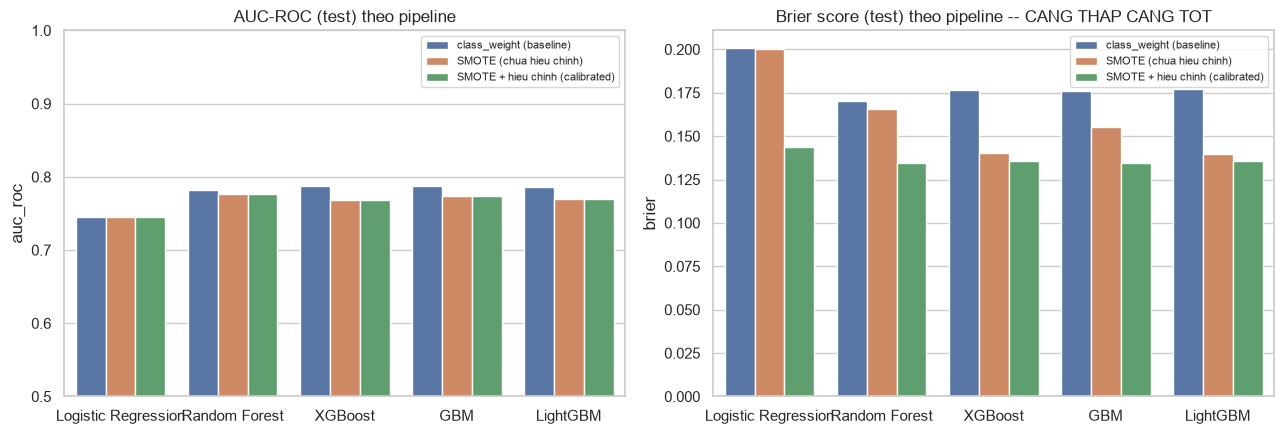

Brier score theo model & pipeline (cang thap cang tot):
pipeline             SMOTE (chua hieu chinh)  SMOTE + hieu chinh (calibrated)  \
model                                                                           
GBM                                   0.1554                           0.1348   
LightGBM                              0.1396                           0.1359   
Logistic Regression                   0.2001                           0.1439   
Random Forest                         0.1655                           0.1348   
XGBoost                               0.1405                           0.1358   

pipeline             class_weight (baseline)  
model                                         
GBM                                   0.1763  
LightGBM                              0.1772  
Logistic Regression                   0.2008  
Random Forest                         0.1702  
XGBoost                               0.1767  


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=resampling_comparison, x="model", y="auc_roc", hue="pipeline", ax=axes[0])
axes[0].set_title("AUC-ROC (test) theo pipeline")
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xlabel("")
axes[0].legend(fontsize=8)

sns.barplot(data=resampling_comparison, x="model", y="brier", hue="pipeline", ax=axes[1])
axes[1].set_title("Brier score (test) theo pipeline -- CANG THAP CANG TOT")
axes[1].set_xlabel("")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

brier_pivot = resampling_comparison.pivot(index="model", columns="pipeline", values="brier")
print("Brier score theo model & pipeline (cang thap cang tot):")
print(brier_pivot.round(4))


**Kết luận Bước 5b:** đọc bảng `resampling_comparison` theo 2 tiêu chí tách biệt —
hiệu năng phân loại (`auc_roc`, `f1`, `g_mean`) và độ tin cậy xác suất (`brier`) —
KHÔNG chỉ nhìn AUC/F1:

- Nếu `brier` của **"SMOTE (chưa hiệu chỉnh)"** xấu hơn (cao hơn) baseline
  `class_weight`, đây là bằng chứng thực nghiệm cho lo ngại ở đầu Bước 5b:
  `risk_score` sau SMOTE bị lệch, **không nên dùng thẳng cho `priority_score`**.
- **"SMOTE + hiệu chỉnh"** thường kéo `brier` về gần (hoặc tốt hơn) baseline — cho thấy
  hiệu chỉnh xác suất là bước bắt buộc nếu muốn dùng SMOTE cho bài toán này, chứ không
  thể dùng thẳng model SMOTE thô.
- Ngay cả khi AUC-ROC/F1/G-mean của một model SMOTE cao hơn baseline, quyết định đổi
  model dùng cho `priority_score` (Bước 8) vẫn cần cân nhắc thêm độ phức tạp vận hành
  (thêm bước calibrate) so với mức cải thiện thực tế. Ở phiên bản hiện tại, **Bước 8
  vẫn dùng `best_model` từ pipeline chính (class_weight)** — thí nghiệm này đóng vai
  trò tài liệu hoá đánh đổi, không tự động thay model.


## Bước 6. Đánh giá hiệu suất mô hình theo metric

Đánh giá 4 mô hình đã tinh chỉnh (Bước 5) trên **tập test** (dữ liệu mô hình chưa từng
thấy) bằng các metric: **AUC-ROC** (chính, vì dữ liệu mất cân bằng), **Accuracy**,
**Precision**, **Recall**, **F1-score**, cùng **Confusion Matrix** và **đường cong ROC**.


In [22]:
metrics_table = build_metrics_table(trained, X_test_t, y_test.to_numpy())
metrics_table


,model,best_params,val_auc,test_auc_roc,test_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_g_mean,test_brier
0,XGBoost,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.775868,0.787950,0.571827,0.763500,0.474973,0.657875,0.551659,0.722510,0.176662
1,GBM,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.774309,0.787769,0.570108,0.761500,0.471953,0.659382,0.550141,0.721970,0.176276
2,LightGBM,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.775773,0.786395,0.569780,0.761167,0.471101,0.651093,0.546662,0.718291,0.177181
3,Random Forest,"{'n_estimators': 400, 'max_depth': 10}",0.777504,0.782725,0.566954,0.776000,0.494769,0.605878,0.544715,0.706704,0.170234
4,Neural Network,"{'hidden_layer_sizes': (32,), 'alpha': 0.001}",0.766689,0.778175,0.544364,0.747500,0.451194,0.654861,0.534276,0.711854,0.192701
5,Logistic Regression,{'C': 10.0},0.722318,0.744591,0.511216,0.732833,0.431548,0.655614,0.520491,0.703443,0.200833


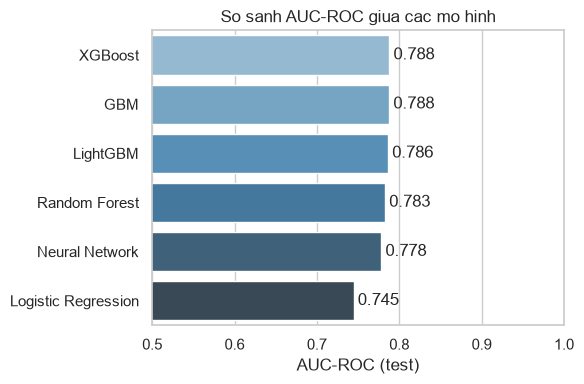

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=metrics_table, x="test_auc_roc", y="model", hue="model", legend=False, palette="Blues_d", ax=ax)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC-ROC (test)")
ax.set_ylabel("")
ax.set_title("So sanh AUC-ROC giua cac mo hinh")
for i, v in enumerate(metrics_table["test_auc_roc"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


Mo hinh tot nhat theo AUC-ROC tren test: XGBoost


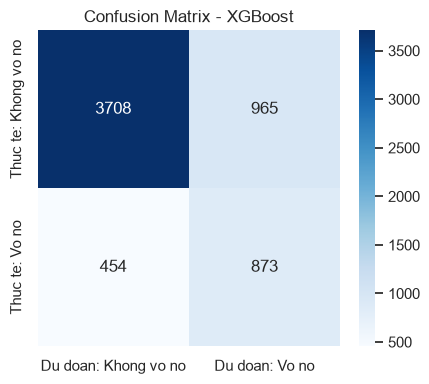

In [24]:
best_model_name = metrics_table.iloc[0]["model"]
best_model = trained[best_model_name]["model"]
print("Mo hinh tot nhat theo AUC-ROC tren test:", best_model_name)

# Confusion matrix cua mo hinh tot nhat (nguong phan loai mac dinh = 0.5)
y_pred_best = (best_model.predict_proba(X_test_t)[:, 1] >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Du doan: Khong vo no", "Du doan: Vo no"],
            yticklabels=["Thuc te: Khong vo no", "Thuc te: Vo no"])
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


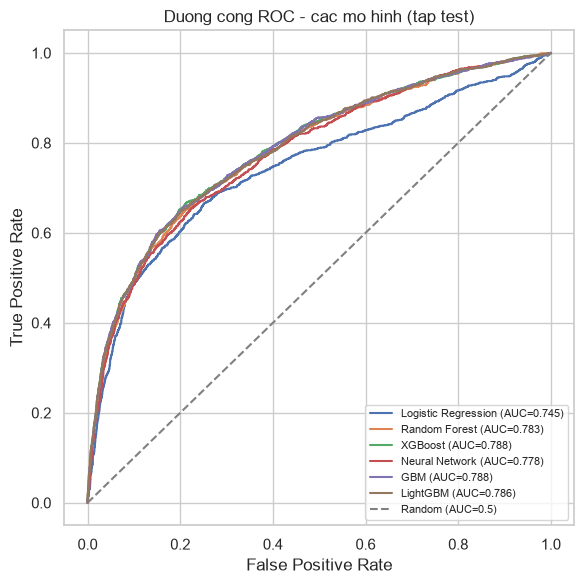

In [25]:
# Duong cong ROC cho tat ca cac mo hinh tren cung mot bieu do
fig, ax = plt.subplots(figsize=(6, 6))
for name, info in trained.items():
    proba = info["model"].predict_proba(X_test_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Duong cong ROC - cac mo hinh (tap test)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


### So sánh với paper gốc Yeh & Lien (2009)

Paper gốc dùng **area ratio trong lift chart** (Table 1) thay vì AUC-ROC để so sánh mô
hình. Area ratio có cùng định nghĩa với hệ số Gini chuẩn hoá, nên ta quy đổi gần đúng
`AUC ≈ (area_ratio + 1) / 2` (xem `src/config.py`) để đối chiếu. Đây là quy đổi tương
đối — không phải con số AUC-ROC do tác giả gốc trực tiếp công bố — nên chênh lệch %
cải thiện dưới đây chỉ mang tính tham khảo.


In [26]:
comparison_table = build_paper_comparison_table(metrics_table)
comparison_table


,model,auc_2026,auc_approx_2009,improvement_pct,note
0,XGBoost,0.787950,NaN,NaN,khong co trong paper goc (2009)
1,GBM,0.787769,NaN,NaN,khong co trong paper goc (2009)
2,LightGBM,0.786395,NaN,NaN,khong co trong paper goc (2009)
3,Random Forest,0.782725,NaN,NaN,khong co trong paper goc (2009)
4,Neural Network,0.778175,0.77,1.061732,"quy doi tu area ratio (Table 1, Yeh & Lien 2009)"
5,Logistic Regression,0.744591,0.72,3.415480,"quy doi tu area ratio (Table 1, Yeh & Lien 2009)"


## Bước 7. Diễn giải mô hình (Model Interpretation)

Dùng **SHAP (SHapley Additive exPlanations)** để xác định các đặc trưng ảnh hưởng mạnh
nhất đến dự báo vỡ nợ của mô hình tốt nhất — quan trọng để giải thích quyết định của mô
hình cho các bên liên quan (không chỉ dựa vào một con số AUC).


In [27]:
from src.interpret import compute_shap_values, top_features_by_shap

shap_values, X_sample = compute_shap_values(best_model, X_test_t, feature_names)
top_features = top_features_by_shap(shap_values, feature_names, top_n=15)
top_features


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,mean_abs_shap
0,num__MAX_DELAY,0.508216
1,num__PAY_1,0.252168
2,num__LIMIT_BAL,0.176697
3,num__AVG_DELAY,0.090529
4,num__BILL_AMT1,0.066757
5,num__PAY_AMT2,0.066650
6,num__PAY_AMT1,0.065537
7,num__PAY_TO_BILL_RATIO,0.064868
8,num__AVG_BILL_AMT,0.060596
9,num__BILL_AMT_TREND,0.054470


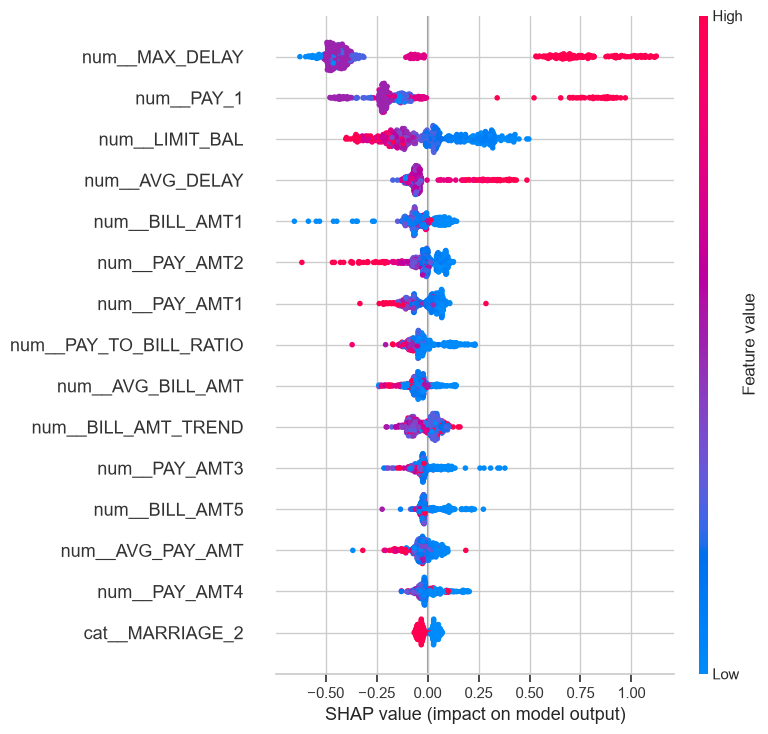

In [28]:
import shap

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=15, show=True)


**Đọc biểu đồ SHAP summary:** mỗi điểm là một khách hàng; trục hoành là mức độ đóng
góp (SHAP value) của đặc trưng đó vào dự báo xác suất vỡ nợ của khách hàng (dương =
đẩy dự báo về phía "vỡ nợ" nhiều hơn); màu đỏ = giá trị đặc trưng cao, xanh = giá trị
đặc trưng thấp. Các đặc trưng liên quan đến `PAY_n` (mức độ trễ hạn) thường đứng đầu
danh sách — khớp với phân tích tương quan ở Bước 2.


## Bước 8. Đề xuất thu hồi nợ

### 8.1. Công thức xếp hạng ưu tiên

```
priority_score = risk_score × mức_độ_trễ_hạn
```

- `risk_score`: xác suất vỡ nợ (0–1) do mô hình tốt nhất (Bước 6) dự báo trên tập test.
- `mức_độ_trễ_hạn`: `max(PAY_1..PAY_6, 0)` — chỉ tính số tháng trễ hạn thực tế (giá trị
  dương), bỏ qua các trạng thái "trả đúng hạn / dùng tín dụng xoay vòng / không phát
  sinh dư nợ" (≤ 0).

Khách hàng có `priority_score` cao nhất là nhóm **vừa rủi ro vỡ nợ cao, vừa đã trễ hạn
nhiều kỳ** — đúng nhóm bộ phận thu hồi nợ nên liên hệ trước, thay vì liên hệ dàn trải
toàn bộ danh sách khách hàng.


In [29]:
risk_scores = best_model.predict_proba(X_test_t)[:, 1]
priority_ranking = build_priority_ranking(X_test, X_test.index.to_series(name="ID"), risk_scores)

print("Top 10 khach hang uu tien thu hoi no cao nhat:")
priority_ranking.head(10)


Top 10 khach hang uu tien thu hoi no cao nhat:


,priority_rank,ID,risk_score,delay_severity,priority_score
0,1,4388,0.892530,8,7.140237
1,2,750,0.878362,8,7.026893
2,3,13713,0.831621,8,6.652966
3,4,13407,0.939739,7,6.578175
4,5,20722,0.939557,7,6.576897
5,6,20255,0.938422,7,6.568957
6,7,9672,0.937248,7,6.560738
7,8,16789,0.936862,7,6.558035
8,9,24168,0.935559,7,6.548910
9,10,29771,0.934093,7,6.538654


**Case study:** kiểm tra tính hợp lý của thứ hạng — so sánh nhóm ưu tiên cao nhất với
nhóm khách hàng có `risk_score` cao nhưng `delay_severity = 0` (rủi ro cao nhưng hiện
chưa trễ hạn, nên chưa cần ưu tiên liên hệ ngay).


In [30]:
print("=> 3 khach hang uu tien cao nhat (rui ro cao + tre han nhieu ky):")
display(priority_ranking.head(3))

high_risk_no_delay = priority_ranking[priority_ranking["delay_severity"] == 0].sort_values(
    "risk_score", ascending=False
).head(3)
print("\n=> Rui ro cao nhung CHUA tre han (khong nam trong nhom uu tien lien he ngay):")
display(high_risk_no_delay)


=> 3 khach hang uu tien cao nhat (rui ro cao + tre han nhieu ky):


,priority_rank,ID,risk_score,delay_severity,priority_score
0,1,4388,0.892530,8,7.140237
1,2,750,0.878362,8,7.026893
2,3,13713,0.831621,8,6.652966



=> Rui ro cao nhung CHUA tre han (khong nam trong nhom uu tien lien he ngay):


,priority_rank,ID,risk_score,delay_severity,priority_score
4203,4204,20818,0.616561,0,0.0
2907,2908,24535,0.607303,0,0.0
5261,5262,13030,0.604190,0,0.0


### 8.2. Phân nhóm ưu tiên & đề xuất hành động cụ thể

Chia danh sách khách hàng theo `priority_score` thành 3 nhóm hành động cụ thể cho bộ
phận thu hồi nợ, dựa trên phân vị (quantile) — cách làm phổ biến khi chưa có ngưỡng
nghiệp vụ cố định, có thể điều chỉnh lại ngưỡng sau khi có phản hồi thực tế:

| Nhóm | Ngưỡng `priority_score` | Đề xuất hành động |
|---|---|---|
| **Cao** | Top 10% | Gọi điện trực tiếp / liên hệ ngay trong tuần, cân nhắc phương án tái cơ cấu nợ |
| **Trung bình** | 10%–40% tiếp theo | Nhắc nợ qua SMS/email tự động, theo dõi sát trong kỳ tới |
| **Thấp** | 60% còn lại | Theo dõi định kỳ theo quy trình thông thường, chưa cần can thiệp thêm |


In [31]:
q90 = priority_ranking["priority_score"].quantile(0.90)
q60 = priority_ranking["priority_score"].quantile(0.60)

def assign_tier(score):
    if score >= q90:
        return "Cao - lien he ngay"
    if score >= q60:
        return "Trung binh - nhac no tu dong"
    return "Thap - theo doi dinh ky"

priority_ranking["tier"] = priority_ranking["priority_score"].apply(assign_tier)

tier_summary = (
    priority_ranking.groupby("tier")
    .agg(
        so_khach_hang=("ID", "count"),
        risk_score_trung_binh=("risk_score", "mean"),
        delay_severity_trung_binh=("delay_severity", "mean"),
    )
    .reindex(["Cao - lien he ngay", "Trung binh - nhac no tu dong", "Thap - theo doi dinh ky"])
)
tier_summary


,so_khach_hang,risk_score_trung_binh,delay_severity_trung_binh
tier,,,
Cao - lien he ngay,600.0,0.870003,2.685000
Trung binh - nhac no tu dong,5400.0,0.374076,0.468148
Thap - theo doi dinh ky,NaN,NaN,NaN


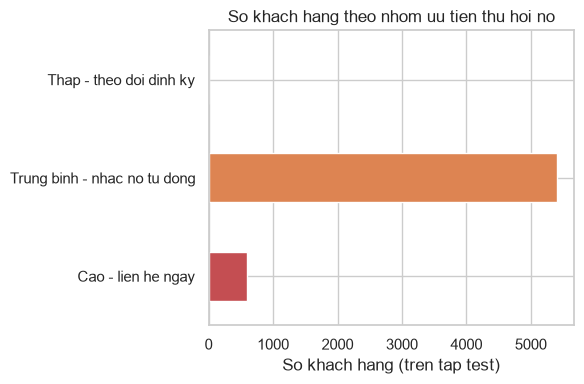

=> Chi can uu tien lien he ngay 600 khach hang (top 10% theo priority_score) thay vi lien he dan trai toan bo 6000 khach hang trong tap test.


In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
tier_summary["so_khach_hang"].plot(kind="barh", ax=ax, color=["#C44E52", "#DD8452", "#55A868"])
ax.set_xlabel("So khach hang (tren tap test)")
ax.set_ylabel("")
ax.set_title("So khach hang theo nhom uu tien thu hoi no")
plt.tight_layout()
plt.show()

print(
    f"=> Chi can uu tien lien he ngay {tier_summary.loc['Cao - lien he ngay', 'so_khach_hang']:.0f} "
    f"khach hang (top 10% theo priority_score) thay vi lien he dan trai toan bo "
    f"{len(priority_ranking)} khach hang trong tap test."
)


## Kết luận

- **Bước 1–3:** dữ liệu 30.000 khách hàng, ~22% vỡ nợ (mất cân bằng); đã làm sạch
  `EDUCATION`/`MARRIAGE`, thêm đặc trưng tổng hợp giảm đa cộng tuyến của `BILL_AMT1-6`,
  chia train/validation/test theo tỷ lệ 60/20/20 (stratified).
- **Bước 4–5:** 6 mô hình (Logistic Regression, Random Forest, XGBoost, Neural Network,
  **GBM, LightGBM** — 2 model thêm ở version 2) được huấn luyện với xử lý mất cân bằng
  phù hợp API từng model (`class_weight`, `scale_pos_weight`, `sample_weight`, hoặc
  oversample thủ công), sau đó tinh chỉnh siêu tham số bằng grid search trên tập
  validation.
- **Bước 5b (version 2):** thí nghiệm so sánh riêng SMOTE vs `class_weight`, kèm kiểm
  tra Brier score để xác nhận `risk_score` có còn đáng tin sau resampling hay không.
  Kết luận: SMOTE chưa hiệu chỉnh có thể làm lệch xác suất; pipeline chính (dùng cho
  `priority_score`) vẫn giữ `class_weight`, không tự động đổi sang model SMOTE.
- **Bước 6:** mô hình tốt nhất được chọn theo AUC-ROC trên tập test, đối chiếu với kết
  quả (quy đổi) của paper gốc Yeh & Lien (2009).
- **Bước 7:** SHAP xác nhận `PAY_n` (mức độ trễ hạn) là nhóm đặc trưng ảnh hưởng mạnh
  nhất đến khả năng vỡ nợ.
- **Bước 8:** công thức `priority_score` và bảng phân nhóm hành động (`tier`) là sản
  phẩm ứng dụng thực tiễn, giúp bộ phận thu hồi nợ tập trung nguồn lực đúng chỗ thay vì
  liên hệ dàn trải toàn bộ danh sách khách hàng.

**Hạn chế:** demo dừng ở mức notebook, chưa tích hợp CRM/hệ thống thu hồi nợ thực tế;
ngưỡng phân nhóm (`tier`) ở Bước 8 là ngưỡng khởi điểm theo phân vị, cần hiệu chỉnh lại
dựa trên phản hồi thực tế của bộ phận thu hồi nợ; việc quy đổi AUC từ area ratio của
paper gốc chỉ mang tính tham khảo tương đối; thí nghiệm SMOTE ở Bước 5b chưa thử các
biến thể khác (SMOTE-Tomek, ADASYN) — có thể mở rộng ở version sau nếu cần.

**File version 2:** `src/models_v2.py`, `src/evaluate_v2.py`,
`src/resampling_experiment_v2.py`, `src/pipeline_v2.py` (chạy: `py -m src.pipeline_v2`),
`notebooks/02_credit_risk_pipeline_v2.ipynb` (file này) — tất cả là file MỚI, không
ghi đè `src/models.py`, `src/evaluate.py`, `src/pipeline.py`,
`notebooks/01_credit_risk_pipeline.ipynb` gốc.
